# Proyek Analisis Data: Brazilian E-Commerce Public Dataset
- **Nama:** Muchlis Ar Wicaksana
- **Email:** CDCC009D6Y2743@student.devacademy.id
- **ID Dicoding:** CDCC009D6Y2743

## Menentukan Pertanyaan Bisnis

- Bagaimana performa penjualan dan revenue dalam beberapa bulan terakhir?
- Bagaimana pengaruh lama waktu pengiriman terhadap tingkat kepuasan (review score) pelanggan?
- Pada hari apa atau jam berapa pelanggan paling aktif melakukan transaksi pembelian?
- Apakah pelanggan cenderung menggunakan cicilan (installments) untuk barang dengan nominal besar?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
# Tabel Orders
orders_df = pd.read_csv('olist_orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
# Tabel Payments
payments_df = pd.read_csv('olist_order_payments_dataset.csv')
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
# Tabel reviews
reviews_df = pd.read_csv('olist_order_reviews_dataset.csv')
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
- pada tabel ```orders_df``` memuat informasi history pesanan seperti waktu pembelian dan waktu pengiriman dan juga status pengiriman
- pada tabel ```payments_df``` memuat informasi tentang detail pembayaran seperti nilai transaksi, jumlah cicilan, dan tipe pembayarannya menggunakan apa
- pada tabel ```reviews_df``` memuat skor kepuasan pelanggan dari setiap ```order_id```

### Assessing Data

In [ ]:
# Cek info dan missing values pada orders_df
orders_df.info()
orders_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
# Cek info dan missing Value pada payments_df
payments_df.info()
payments_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [ ]:
# Cek info dan missing value pada reviews_df
reviews_df.info()
reviews_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


**Insight:**
- Tipe data pada kolom yang menampilkan tanggal atau waktu di ```orders_df``` masih berupa object dan harus diubah ke datetime.
- terdapat beberapa missing value pada tabel ```orders_df``` contohnya di kolom `order_delivered_customer_date` untuk kolom ini wajar karena pesanan yang dibatalkan atau masih proses tidak memiliki tanggal kirim.
- pada tabel ```payments_df``` tipe datanya sudah sesuai dan tidak ada missing value
- pada tabel `payments_df` ada cukup banyak missing value di kolo `review_comment_title` dan `review_comment_message` dan juga ketidak sesuaian tipe data pada kolom yang menampilkan tanggal/waktu. Tetapi tidak akan berpengaruh pada data analisis karena kita hanya akan menggunakan kolom `review_score`

### Cleaning Data

In [ ]:
# Mengubah tipe data tanggal menjadi datetime pada tabel orders
datetime_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [ ]:
# Menangani missin value -> Drop baris yang tidak memiliki tanggal kirim
orders_df.dropna(subset=['order_delivered_carrier_date'], inplace=True)

In [ ]:
# Membuat kolom baru untuk lama pengiriman (hari)
orders_df['delivery_time_days'] = (orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']).dt.days

In [ ]:
# Mengekstrak Hari dan Jam pembelian untuk melakukan analisis waktu
orders_df['purchase_day'] = orders_df['order_purchase_timestamp'].dt.day_name()
orders_df['purchase_hour'] = orders_df['order_purchase_timestamp'].dt.hour

In [ ]:
# tampilkan order_id, waktu lama pengiriman, hari pembelian, dan jam pembelian
orders_df[['order_id', 'delivery_time_days', 'purchase_day', 'purchase_hour']].head()

,order_id,delivery_time_days,purchase_day,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,Monday,10
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,Tuesday,20
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,Wednesday,8
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,Saturday,19
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,Tuesday,21


In [ ]:
# Menhapus kolom yang tidak digunakan pada dataframe reviews_df
unused_review_columns = [
    'review_comment_title',
    'review_comment_message',
    'review_creation_date',
    'review_answer_timestamp'
]
reviews_df.drop(columns=unused_review_columns, inplace=True)
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review_id     99224 non-null  object
 1   order_id      99224 non-null  object
 2   review_score  99224 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.3+ MB


In [ ]:
# Menghapus kolom yang tidak digunakan pada dataframe payments_df
payments_df.drop(columns=['payment_sequential'], inplace=True)
payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_type          103886 non-null  object 
 2   payment_installments  103886 non-null  int64  
 3   payment_value         103886 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


**Insight:**
- Berhasil mengubah tipe data tanggal menjadi datetime agar mudah diolah
- Baris `order_delivered_carrier_date` dihapus untuk menghindari bias saat menghitung
- berhasil menambahkan tiga fitur yaitu : `delivery_time_days` yang memberikan kita informasi tentang durasi pengiriman, dan juga kolom `purchase_day`, dan `purchase_hour` untuk memberikan kita informasi tentang hari dan jam pembelian
- berhasil menghapus kolom yang tidak terpakai pada `reviews_df` dan `payments_df` untuk menghemat memori saat load nya

## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
# Menggabungkan ketiga tabel agar mudah di analisis
orders_payments = pd.merge(
    left=orders_df,
    right=payments_df,
    how='inner',
    on='order_id'
)

# Merge semua tabelnya
all_df = pd.merge(
    left=orders_payments,
    right=reviews_df,
    how='inner',
    on='order_id'
)
all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,purchase_day,purchase_hour,payment_type,payment_installments,payment_value,review_id,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,Monday,10,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,Monday,10,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,Monday,10,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,Tuesday,20,boleto,1,141.46,8d5266042046a06655c8db133d120ba5,4
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,Wednesday,8,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5


In [ ]:
all_df.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,purchase_day,purchase_hour,payment_type,payment_installments,payment_value,review_id,review_score
count,101816,101816,101816,101816,101802,101816,100646,101816,100646.000000,101816,101816.000000,101816,101816.000000,101816.000000,101816,101816.000000
unique,96926,96926,3,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,4,NaN,NaN,96730,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,9af2372a1e49340278e7c1ef8d749f34,delivered,NaN,NaN,NaN,NaN,NaN,NaN,Monday,NaN,credit_card,NaN,NaN,f28281373ab8815bafafe371218f02ce,NaN
freq,29,29,100647,NaN,NaN,NaN,NaN,NaN,NaN,16499,NaN,75325,NaN,NaN,29,NaN
mean,NaN,NaN,NaN,2017-12-31 00:20:44.736780032,2017-12-31 11:36:20.256046080,2018-01-03 05:52:33.642306304,2018-01-12 21:08:44.883830528,2018-01-23 19:16:42.750059264,12.069223,NaN,14.784346,NaN,2.853432,152.628796,NaN,4.128968
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-10-04 09:43:32,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-20 00:00:00,0.000000,NaN,0.000000,NaN,0.000000,0.000000,NaN,1.000000
25%,NaN,NaN,NaN,2017-09-11 15:36:13.750000128,2017-09-12 04:26:08.750000128,2017-09-13 21:45:42.500000,2017-09-21 22:35:09,2017-10-03 00:00:00,6.000000,NaN,11.000000,NaN,1.000000,56.780000,NaN,4.000000
50%,NaN,NaN,NaN,2018-01-18 18:22:30,2018-01-19 02:38:28.500000,2018-01-23 15:29:42.500000,2018-02-01 02:30:19,2018-02-15 00:00:00,10.000000,NaN,15.000000,NaN,1.000000,99.900000,NaN,5.000000
75%,NaN,NaN,NaN,2018-05-04 03:45:19.249999872,2018-05-04 14:53:29.500000,2018-05-07 15:19:00,2018-05-15 15:58:15.500000,2018-05-25 00:00:00,15.000000,NaN,19.000000,NaN,4.000000,170.972500,NaN,5.000000
max,NaN,NaN,NaN,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,208.000000,NaN,23.000000,NaN,24.000000,13664.080000,NaN,5.000000


**Insight:**
- berhasil membuat tabel gabungan dengan menggabungkan semua tabel dengan menggunakan `order_id` sebagai primary key
- kita dapat melihat persebaran data nilai pembayaran (`payment_value`), rata-rata score ulasan (`review_score`), dan rentang lama waktu pengiriman dari tabel `all_df` menggunakan fungsi `describe()`

## Visualization & Explanatory Analysis

### Pertanyaan 1:

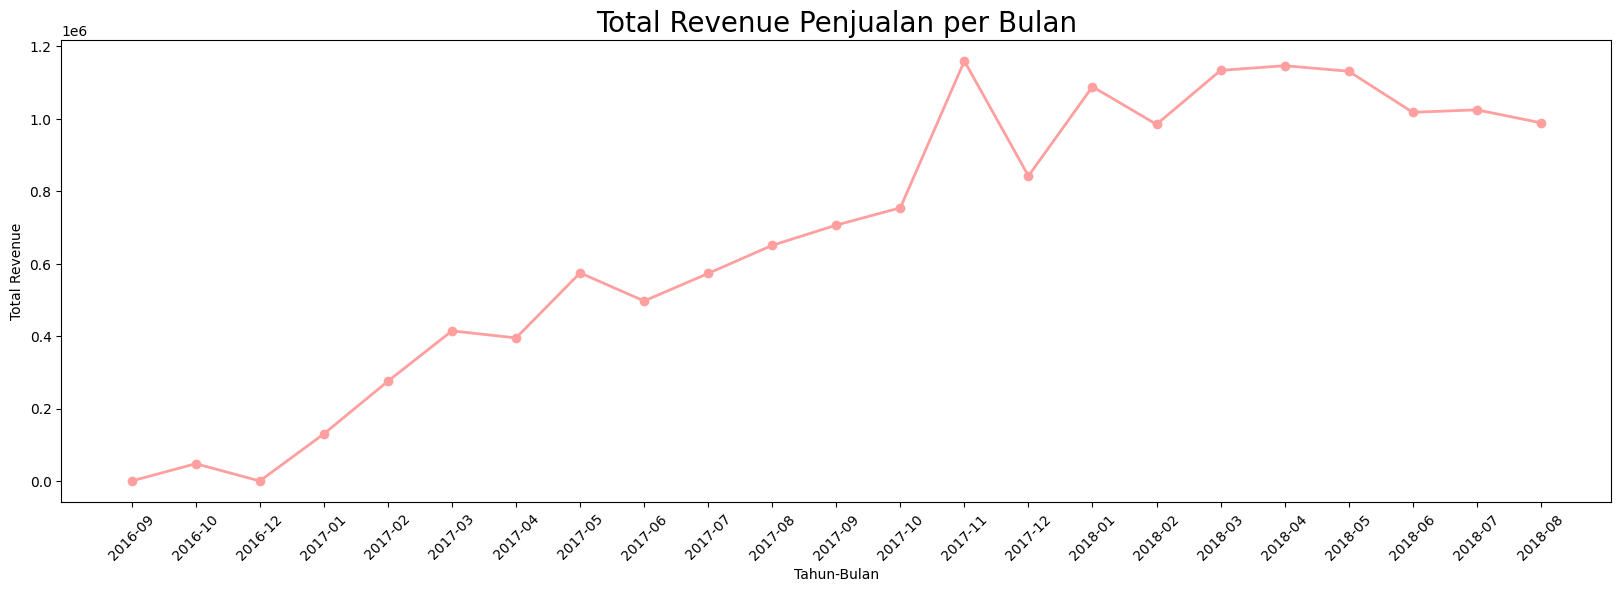

In [ ]:
# Mengambil format Tahun-Bulan (YYYY-MM) dari order_purchase_timestamp
all_df['order_month_year'] = all_df['order_purchase_timestamp'].dt.to_period('M')

# Agregasi total pendapatan per bulan
monthly_revenue = all_df.groupby('order_month_year')['payment_value'].sum().reset_index()
monthly_revenue['order_month_year'] = monthly_revenue['order_month_year'].astype(str) # ubah ke string

# 3. FILTERING: Membuang data bulan September 2018 (2018-09) dan seterusnya karena tidak lengkap
monthly_revenue = monthly_revenue[monthly_revenue['order_month_year'] < '2018-09']

# Visual
plt.figure(figsize=(20, 6))
plt.plot(monthly_revenue['order_month_year'], monthly_revenue['payment_value'], marker='o', linewidth=2, color='#FF9F9F')
plt.title('Total Revenue Penjualan per Bulan', loc='center', fontsize='20')
plt.xlabel('Tahun-Bulan')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_452/2502483983.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


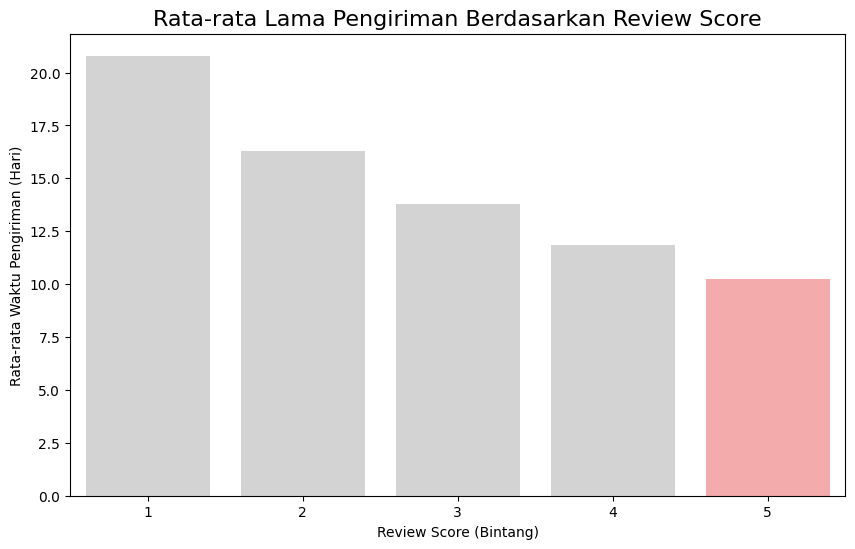

In [ ]:
# Agregasi rata-rata waktu pengiriman berdasarkan review score
avg_delivery_by_score = all_df.groupby('review_score')['delivery_time_days'].mean().reset_index()

# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(
    x='review_score',
    y='delivery_time_days',
    data=avg_delivery_by_score,
    palette=["#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#FF9F9F"]
)
plt.title('Rata-rata Lama Pengiriman Berdasarkan Review Score', fontsize=16)
plt.xlabel('Review Score (Bintang)')
plt.ylabel('Rata-rata Waktu Pengiriman (Hari)')
plt.show()

### Pertanyaan 3:

/tmp/ipykernel_452/319124683.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = all_df.groupby(['purchase_day', 'purchase_hour']).size().unstack(fill_value=0)


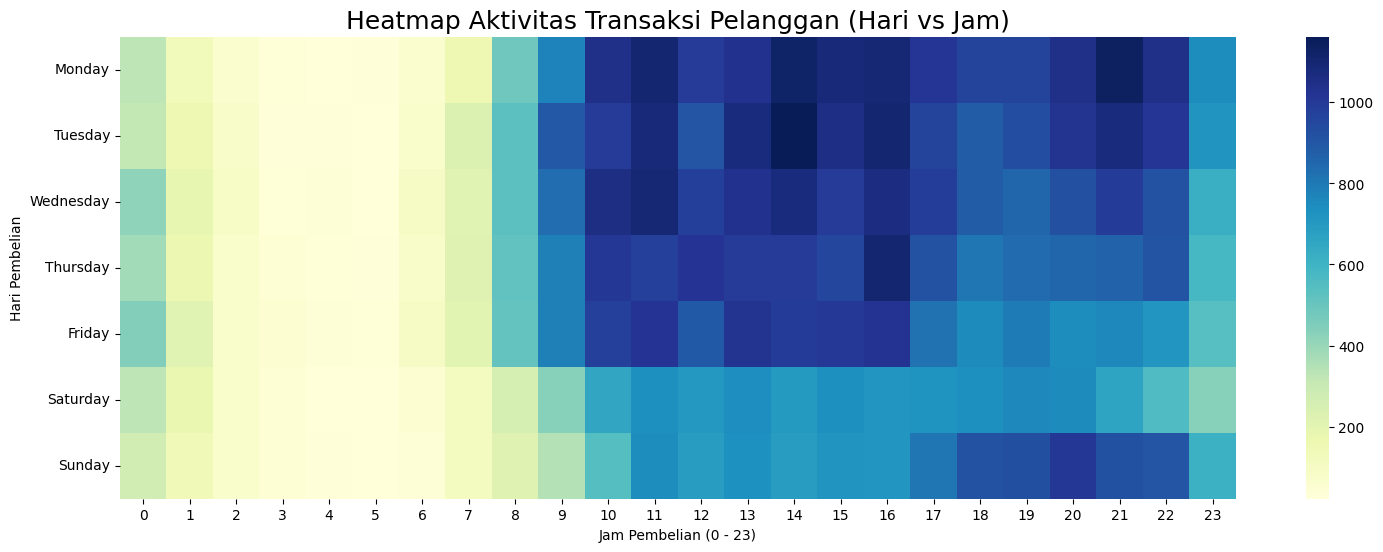

In [ ]:
# Menyiapka urutan hari agar terurut di grafik
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
all_df['purchase_day'] = pd.Categorical(all_df['purchase_day'], categories=days_order, ordered=True)

# Membuat tabel pivot untuk Heatmap (Hari vs Jam)
heatmap_data = all_df.groupby(['purchase_day', 'purchase_hour']).size().unstack(fill_value=0)

# Visualisasi Heatmap
plt.figure(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, fmt='d')
plt.title('Heatmap Aktivitas Transaksi Pelanggan (Hari vs Jam)', fontsize=18)
plt.xlabel('Jam Pembelian (0 - 23)')
plt.ylabel('Hari Pembelian')
plt.show()

### Pertanyaan 4:

/tmp/ipykernel_452/361787038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


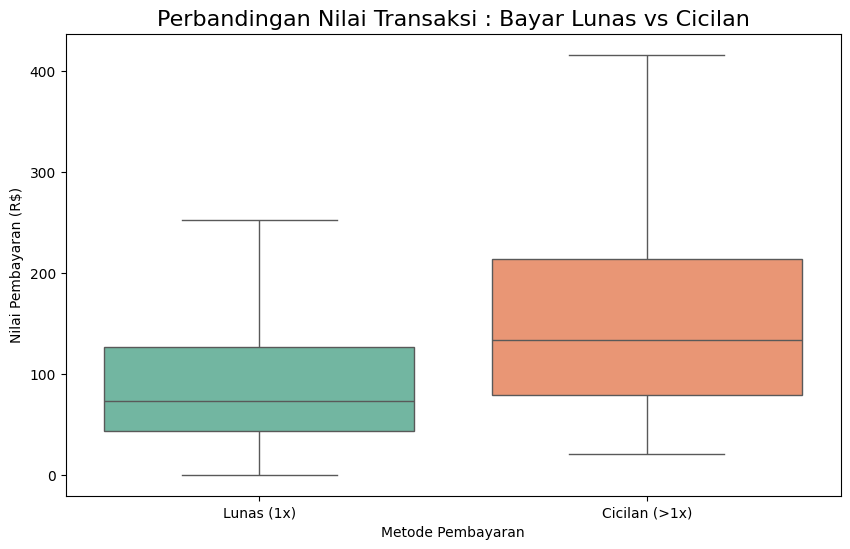

In [ ]:
# Memisahkan transaksi menjadi 2 kategori: Lunas (1x Bayar) dan Cicilan (>2x Bayar)
# Kecualikan transaksi dengan payment_installments = 0 data agar lebih akurat
payments_valid = all_df[all_df['payment_installments'] > 0].copy()
payments_valid['is_installment'] = payments_valid['payment_installments'].apply(lambda x: 'Cicilan (>1x)' if x > 1 else 'Lunas (1x)')

# Visualisasi dengan Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='is_installment',
    y='payment_value',
    data=payments_valid,
    showfliers=False, # Menghilangkan outlier di visual agar mudah terbaca
    palette='Set2'
)
plt.title('Perbandingan Nilai Transaksi : Bayar Lunas vs Cicilan', fontsize=16)
plt.xlabel('Metode Pembayaran')
plt.ylabel('Nilai Pembayaran (R$)')
plt.show()

**Insight:**
- Terdapat peningkatan pesat revenue hingga titik tertinggi di bulan November 2017, dan performa tersebut relatif stabil sepanjang tahun 2018.
- Keterlambatan pengiriman berbanding lurus dengan kepuasan. Rating bintan 1 rata-rata mengalami waktu pengiriman sampai 20 hari
- Pelanggan paling aktif berbelanja di hari kerja yaitu senin sampai jumat antara jam 10 pagi hinga 4 sore, dibandingkan saat akhir pekan.
- Pengguna metode cicilan secara konsisten memiliki total nominal payment value lebih besar dibandingkan yang membayar lunas sekaligus.

## Analisis Lanjutan (Opsional)

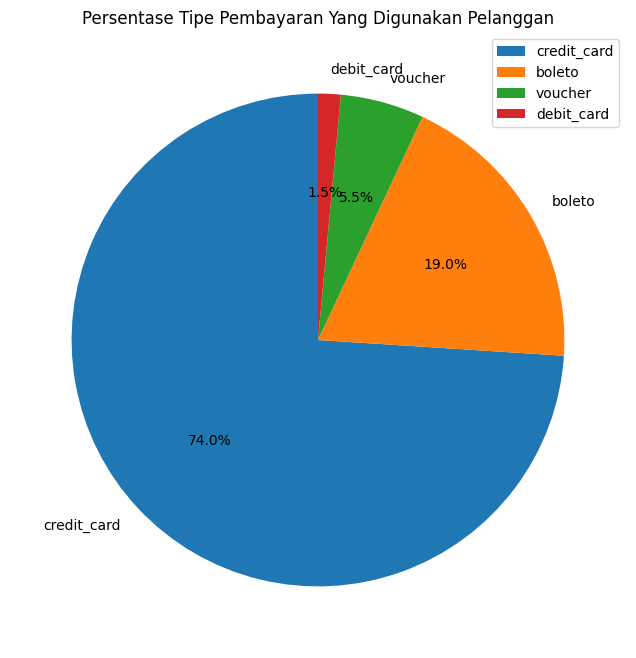

In [ ]:
# Menghitung persentase tipe pembayaran yang paling sering digunakan
payment_types = all_df['payment_type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(payment_types, labels=payment_types.index, autopct='%1.1f%%', startangle=90)
plt.title('Persentase Tipe Pembayaran Yang Digunakan Pelanggan')
plt.legend()
plt.show()

In [ ]:
# 1. Load data customers
customers_df = pd.read_csv("olist_customers_dataset.csv")

# 2. Gabungkan all_df yang lama dengan data customers
all_df_baru = pd.merge(
    left=all_df,
    right=customers_df,
    how="inner",
    on="customer_id"
)

# 3. Ekspor ulang dan timpa file all_data.csv yang lama
all_df_baru.to_csv("all_data.csv", index=False)

print("Data berhasil diperbarui! Silakan refresh atau jalankan ulang Streamlit.")

Data berhasil diperbarui! Silakan refresh atau jalankan ulang Streamlit.


## Conclusion

- Conclution pertanyaan 1 : Performa penjualan mengalami tren pertumbuhan yang sangat baik sejak awal 2017 dan mencapai puncak pendapatan pada sekitar bulan November. Memasuki 2018, perusahaan berhasil mempertahankan tingkat penjualan secara stabil.
- Conclution pertanyaan 2 : Lama waktu pengiriman merupakan indikator vital terhadap tingkat kepuasan pelanggan. Terdapat korelasi kuat dimana pesanan yang memiliki waktu pengiriman sangat lama menerima penilaian buruk. Batas aman pengiriman untuk mendapatkan bintang 5 adalah dibawah 10 hari
- Conclution pertanyaan 3 : Mayoritas aktivitas transaksi berpusat pada hari senin hingga jumat selama jam 10.00 - 16.00 dan malah hari jam 20.00 - 22.00, ini menandakan bahwa konsumen lebih suka belanja di sela sela aktivitas mereka, bukan di akhir pekan.
- Conclution pertanyaan 4 : Pelanggan memiliki keccenderungan yang sangat jelas untuk memanfaatkan fitur installments ketika mereka membeli barang dengan nominal yang tinggi. Rata-rata pemayaran pada transaksi installments jauh lebih tinggi dibandingkan transaksi yang dibayar lunas langusng
- Conclution analisis tambahan : mayoritas pelanggan sangat bergantung pada penggunaan credit card sebagai metode transaksi utama. Hal ini menandakan bahwa perusahaan harus menjadikan credit card sebagai prioritas operasional agar tidak terjadi failed transaction. Selain itu, integrasi pembayaran Boleto tetap harus dipertahankan karena berhasil menjangkau segemen pelanggan yang mungkin belum memilii akses perbankan digital.